# Word2Vec: Learning Word Representations

This notebook walks through:
1. **Theory** — what Word2Vec is and how it works
2. **Train from scratch** — build a Word2Vec model on a custom corpus
3. **Explore embeddings** — similarity, analogies, vector arithmetic
4. **Visualize** — PCA plot of the learned embedding space
5. **Pre-trained vectors** — use Google News 300-dimensional vectors

## 1. What is Word2Vec?

**Word2Vec** is a shallow neural network that learns dense vector representations (embeddings) for words by training on a large text corpus.

The core idea comes from the **Distributional Hypothesis**:
> *"A word is known by the company it keeps."* — J.R. Firth (1957)

Words that appear in similar contexts will have similar vector representations. For example, `cat` and `dog` both appear near words like `pet`, `fur`, `feed`, so their vectors end up close together in the embedding space.

---

### Why not one-hot encoding?

Traditional one-hot vectors have two major problems:
- **Sparse**: a vocabulary of 50,000 words gives a 50,000-dimensional vector with only one `1`
- **No semantics**: every word is equally distant from every other word

Word2Vec produces **dense, low-dimensional** vectors (typically 100–300 dims) that encode semantic meaning.

## 2. Word2Vec Architectures

Word2Vec has two architectures:

### CBOW — Continuous Bag of Words
**Predicts a target word from its surrounding context words.**

```
Context: [the, ___, rules, the]  →  Target: king
```

- Averages the context word vectors
- Faster to train, works better for frequent words

### Skip-gram
**Predicts surrounding context words given a single target word.**

```
Target: king  →  Predict: [the, queen, rules, the]
```

- Works better for rare words and small datasets
- Slower to train but generally produces higher quality embeddings

---

### Window Size
The **window size** controls how many words on each side of the target are considered context.

```
Sentence:  The  king  rules  the  kingdom  with  power
                  ^                           
             target word
window=2:  [The, king, rules, the]  ← 2 words left, 2 words right
```

## 3. Training Objective

For Skip-gram, the model maximizes:

$$\frac{1}{T} \sum_{t=1}^{T} \sum_{-c \leq j \leq c, j \neq 0} \log P(w_{t+j} \mid w_t)$$

Where:
- $T$ = number of words in corpus
- $c$ = window size
- $P(w_{t+j} \mid w_t)$ = probability of context word given target word (computed via softmax)

In practice, **Negative Sampling** is used instead of full softmax — for each positive (word, context) pair, sample $k$ random negative words and train the model to distinguish real context from noise. This makes training much faster.

---

The model has two weight matrices:
- **Input matrix** $W$ — one row per word (the "word" embedding)
- **Output matrix** $W'$ — one column per word (the "context" embedding)

After training, we discard $W'$ and use $W$ as our word embeddings.

In [33]:
# import sys, subprocess
# subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib", "scikit-learn", "gensim"], check=True)

In [34]:
import gensim
from gensim.models import Word2Vec, KeyedVectors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Gensim version:", gensim.__version__)

Gensim version: 4.3.2


## 4. Train Word2Vec from Scratch

We build a small corpus covering royalty, geography, animals, and technology. Even on this tiny dataset, Word2Vec will learn meaningful relationships.

In [35]:
sentences = [
    # Royalty
    ["the", "king", "rules", "the", "kingdom", "with", "power"],
    ["the", "queen", "rules", "the", "kingdom", "with", "grace"],
    ["the", "king", "and", "queen", "live", "in", "the", "castle"],
    ["the", "prince", "will", "become", "king", "one", "day"],
    ["the", "princess", "will", "become", "queen", "one", "day"],
    # Gender
    ["the", "man", "is", "strong", "and", "powerful"],
    ["the", "woman", "is", "strong", "and", "graceful"],
    ["the", "boy", "plays", "in", "the", "park"],
    ["the", "girl", "plays", "in", "the", "park"],
    ["the", "man", "and", "woman", "walked", "together"],
    ["the", "boy", "and", "girl", "played", "together"],
    # Countries and capitals
    ["paris", "is", "the", "capital", "of", "france"],
    ["berlin", "is", "the", "capital", "of", "germany"],
    ["london", "is", "the", "capital", "of", "england"],
    ["madrid", "is", "the", "capital", "of", "spain"],
    ["rome", "is", "the", "capital", "of", "italy"],
    ["france", "and", "germany", "are", "countries", "in", "europe"],
    ["england", "and", "spain", "are", "countries", "in", "europe"],
    # Animals
    ["the", "dog", "barks", "at", "the", "cat"],
    ["the", "cat", "chases", "the", "mouse"],
    ["dog", "and", "cat", "are", "common", "pets"],
    ["the", "dog", "runs", "fast", "in", "the", "park"],
    # Technology
    ["python", "is", "a", "great", "language", "for", "machine", "learning"],
    ["machine", "learning", "uses", "data", "to", "learn", "patterns"],
    ["deep", "learning", "is", "a", "subset", "of", "machine", "learning"],
    ["neural", "networks", "power", "deep", "learning", "models"],
    ["python", "is", "used", "for", "data", "science", "and", "machine", "learning"],
    # Nature
    ["the", "river", "flows", "through", "the", "city"],
    ["the", "ocean", "is", "vast", "and", "deep"],
    ["water", "flows", "from", "mountains", "to", "the", "ocean"],
    ["the", "mountain", "is", "tall", "and", "covered", "in", "snow"],
]

print(f"Corpus: {len(sentences)} sentences")
vocab = set(w for s in sentences for w in s)
print(f"Unique words: {len(vocab)}")

Corpus: 31 sentences
Unique words: 88


In [36]:
model = Word2Vec(
    sentences=sentences,
    vector_size=50,   # embedding dimensionality
    window=3,         # context window size (words on each side)
    min_count=1,      # include words that appear at least once
    sg=1,             # 1 = Skip-gram, 0 = CBOW
    negative=5,       # number of negative samples
    epochs=200,
    seed=42
)

print("Model trained.")
print(f"Vocabulary size: {len(model.wv)}")
print(f"Vector shape for 'king': {model.wv['king'].shape}")

Model trained.
Vocabulary size: 88
Vector shape for 'king': (50,)


## 5. Exploring Word Vectors

### 5a. Word Similarity

Similarity is measured by **cosine similarity** between two word vectors:

$$\text{similarity}(\vec{u}, \vec{v}) = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \|\vec{v}\|}$$

- Score near **+1** → words are semantically similar
- Score near **0** → words are unrelated
- Score near **-1** → words are used in opposite contexts

In [37]:
print("=== Most Similar Words ===")
for word in ['king', 'machine', 'paris', 'dog']:
    similar = model.wv.most_similar(word, topn=4)
    print(f"\n'{word}':")
    for w, score in similar:
        print(f"  {w:12} {score:.4f}")

=== Most Similar Words ===

'king':
  day          0.9942
  become       0.9941
  live         0.9940
  prince       0.9939

'machine':
  used         0.9962
  learning     0.9960
  great        0.9956
  science      0.9949

'paris':
  the          0.9914
  mountain     0.9906
  covered      0.9902
  flows        0.9902

'dog':
  in           0.9962
  pets         0.9949
  and          0.9937
  at           0.9936


In [38]:
print("=== Pairwise Similarity Scores ===")
print(f"{'Word 1':10}  {'Word 2':10}  {'Similarity':>10}")
print("-" * 36)

pairs = [
    ('king',   'queen'),    # should be high
    ('man',    'woman'),    # should be high
    ('paris',  'berlin'),   # both capitals
    ('dog',    'cat'),      # both pets
    ('france', 'paris'),    # country / capital
    ('python', 'learning'), # both in ML context
    ('king',   'ocean'),    # unrelated
    ('dog',    'mountain'), # unrelated
]

for w1, w2 in pairs:
    score = model.wv.similarity(w1, w2)
    print(f"{w1:10}  {w2:10}  {score:>10.4f}")

=== Pairwise Similarity Scores ===
Word 1      Word 2      Similarity
------------------------------------
king        queen           0.9934
man         woman           0.9917
paris       berlin          0.9850
dog         cat             0.9933
france      paris           0.9851
python      learning        0.9951
king        ocean           0.9873
dog         mountain        0.9897


## 5b. Vector Arithmetic and Analogies

The most famous property of Word2Vec is that **semantic relationships are encoded as linear directions** in the vector space:

```
king - man + woman ≈ queen
paris - france + germany ≈ berlin
```

This works because the model encodes:
- The direction `man → woman` as the "gender" direction
- The direction `france → paris` as the "country → capital" direction

The `most_similar(positive=[...], negative=[...])` API lets us do this arithmetic directly.

In [39]:
print("=== Word Analogies: A - B + C = ? ===")

analogies = [
    # (positive, negative, description)
    (['king',  'woman'], ['man'],    'king - man + woman'),
    (['queen', 'man'],   ['woman'],  'queen - woman + man'),
    (['paris', 'france'],['germany'],'paris - france + germany'),
    (['berlin','germany'],['france'],'berlin - germany + france'),
]

for positive, negative, desc in analogies:
    result = model.wv.most_similar(positive=positive, negative=negative, topn=3)
    top_word = result[0][0]
    top_score = result[0][1]
    print(f"\n  {desc} ≈ '{top_word}' (score: {top_score:.4f})")
    print(f"  Top 3: {[(w, round(s,3)) for w, s in result]}")

=== Word Analogies: A - B + C = ? ===

  king - man + woman ≈ 'become' (score: 0.9876)
  Top 3: [('become', 0.988), ('day', 0.987), ('prince', 0.986)]

  queen - woman + man ≈ 'will' (score: 0.9875)
  Top 3: [('will', 0.987), ('prince', 0.986), ('princess', 0.986)]

  paris - france + germany ≈ 'flows' (score: 0.9838)
  Top 3: [('flows', 0.984), ('city', 0.983), ('covered', 0.983)]

  berlin - germany + france ≈ 'grace' (score: 0.9834)
  Top 3: [('grace', 0.983), ('is', 0.983), ('walked', 0.982)]


In [40]:
print("=== Odd One Out ===")

groups = [
    ['king', 'queen', 'prince', 'dog'],
    ['paris', 'berlin', 'london', 'machine'],
    ['python', 'learning', 'deep', 'cat'],
]

for group in groups:
    odd = model.wv.doesnt_match(group)
    print(f"  {group}  →  odd one out: '{odd}'")

=== Odd One Out ===
  ['king', 'queen', 'prince', 'dog']  →  odd one out: 'dog'
  ['paris', 'berlin', 'london', 'machine']  →  odd one out: 'machine'
  ['python', 'learning', 'deep', 'cat']  →  odd one out: 'cat'


## 6. Visualizing the Embedding Space

Word vectors live in 50-dimensional space — we can't visualize that directly. We use **PCA (Principal Component Analysis)** to project down to 2D while preserving as much variance as possible.

Words that are semantically related should cluster together in the 2D plot.

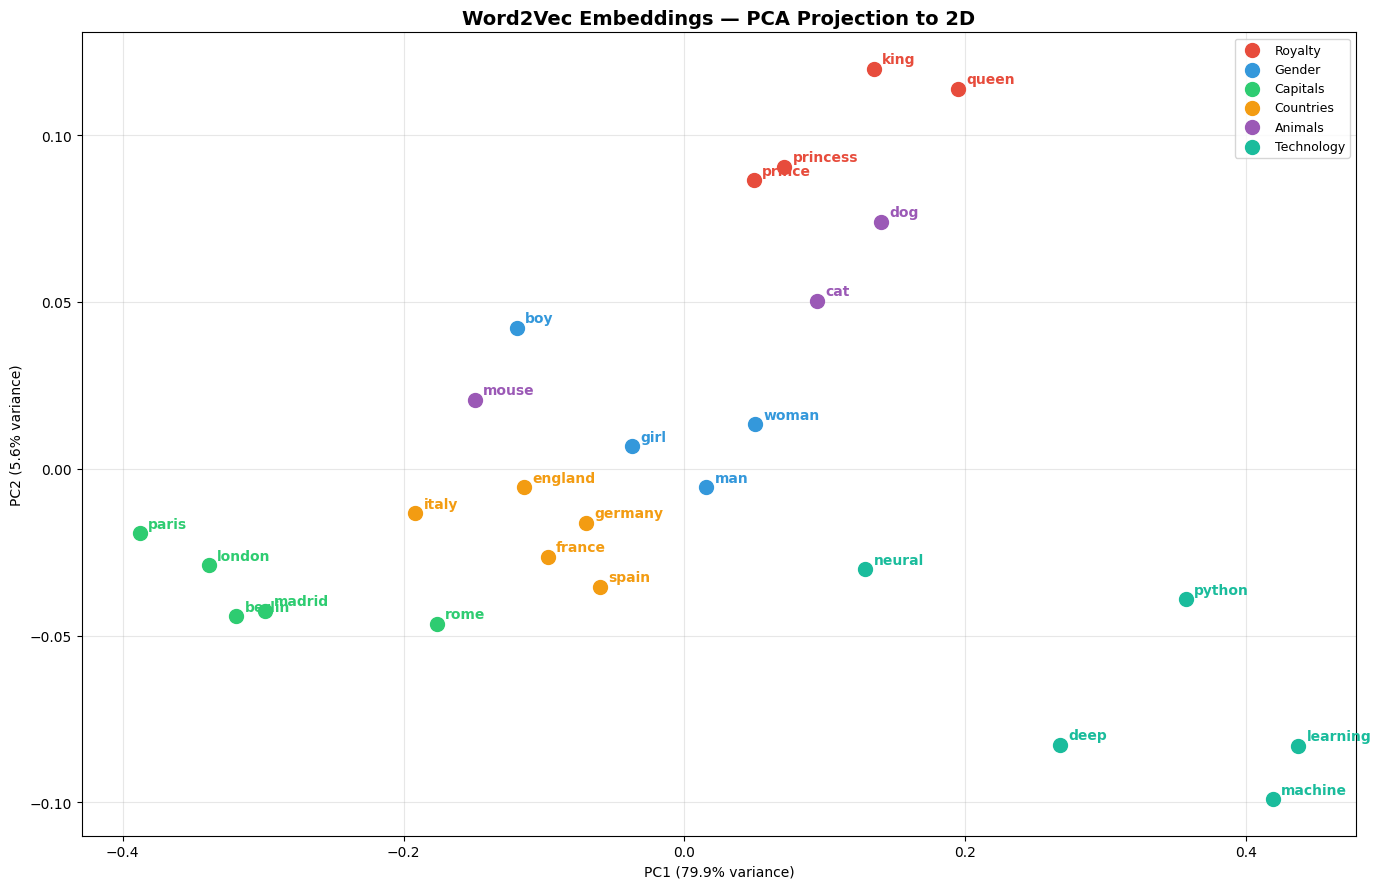

Total variance explained by 2 PCs: 85.5%


In [41]:
words_to_plot = {
    'Royalty':     ['king', 'queen', 'prince', 'princess'],
    'Gender':      ['man', 'woman', 'boy', 'girl'],
    'Capitals':    ['paris', 'berlin', 'london', 'madrid', 'rome'],
    'Countries':   ['france', 'germany', 'england', 'spain', 'italy'],
    'Animals':     ['dog', 'cat', 'mouse'],
    'Technology':  ['python', 'machine', 'learning', 'deep', 'neural'],
}

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

all_words  = [w for group in words_to_plot.values() for w in group]
all_vecs   = np.array([model.wv[w] for w in all_words])

pca = PCA(n_components=2)
reduced = pca.fit_transform(all_vecs)

fig, ax = plt.subplots(figsize=(14, 9))

idx = 0
for (group_name, group_words), color in zip(words_to_plot.items(), colors):
    n = len(group_words)
    xs = reduced[idx:idx+n, 0]
    ys = reduced[idx:idx+n, 1]
    ax.scatter(xs, ys, color=color, s=100, label=group_name, zorder=3)
    for i, word in enumerate(group_words):
        ax.annotate(word, (xs[i], ys[i]),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=10, color=color, fontweight='bold')
    idx += n

ax.set_title("Word2Vec Embeddings — PCA Projection to 2D", fontsize=14, fontweight='bold')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%")

## 7. Pre-trained Google News Vectors

Google trained Word2Vec on ~100 billion words from Google News articles, producing 300-dimensional vectors for 3 million words and phrases.

Pre-trained vectors capture far richer semantics than we can learn from a tiny corpus — they encode knowledge from billions of real-world sentences.

**Download** (one-time, ~1.65 GB):
```bash
wget -c "https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz"
```

**`limit=500000`** loads only the 500K most frequent words, which saves memory while keeping all common words.

> Skip this section if you don't have the file downloaded.

In [42]:
# Uncomment the wget line if you need to download the file
import gensim.downloader as api
pretrained = api.load('word2vec-google-news-300')


import os
# PRETRAINED_PATH = '~/gensim-data/word2vec-google-news-300/'
PRETRAINED_PATH = '/Users/takshpatel/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz'

if os.path.exists(PRETRAINED_PATH):
    print("Loading pre-trained vectors (this takes ~1-2 minutes)...")
    pretrained = KeyedVectors.load_word2vec_format(PRETRAINED_PATH, binary=True, limit=500000)
    print(f"Loaded. Vocabulary: {len(pretrained)} words, Vector size: {pretrained.vector_size}")
else:
    print("Pre-trained file not found. Download it first or continue with the custom model.")
    pretrained = None

Loading pre-trained vectors (this takes ~1-2 minutes)...
Loaded. Vocabulary: 500000 words, Vector size: 300


In [43]:
if pretrained:
    print("=== Most Similar (Pre-trained) ===")
    for word in ['cricket', 'facebook', 'man', 'king']:
        print(f"\n'{word}':")
        for w, s in pretrained.most_similar(word, topn=5):
            print(f"  {w:25} {s:.4f}")

=== Most Similar (Pre-trained) ===

'cricket':
  cricketing                0.8372
  cricketers                0.8166
  Test_cricket              0.8095
  Twenty##_cricket          0.8068
  Twenty##                  0.7624

'facebook':
  Facebook                  0.7564
  FaceBook                  0.7077
  twitter                   0.6989
  myspace                   0.6942
  Twitter                   0.6642

'man':
  woman                     0.7664
  boy                       0.6825
  teenager                  0.6587
  teenage_girl              0.6148
  girl                      0.5922

'king':
  kings                     0.7138
  queen                     0.6511
  monarch                   0.6413
  crown_prince              0.6204
  prince                    0.6160


In [44]:
if pretrained:
    print("=== Analogies (Pre-trained 300-dim vectors) ===")

    analogies_pretrained = [
        (['king',  'woman'], ['man'],    'king - man + woman'),
        (['INR',   'England'], ['India'], 'INR - India + England'),
        (['Paris', 'Germany'],['France'],'Paris - France + Germany'),
    ]

    for positive, negative, desc in analogies_pretrained:
        result = pretrained.most_similar(positive=positive, negative=negative, topn=3)
        print(f"\n  {desc}")
        for w, s in result:
            print(f"    {w:20} {s:.4f}")

=== Analogies (Pre-trained 300-dim vectors) ===

  king - man + woman
    queen                0.7118
    monarch              0.6190
    princess             0.5902

  INR - India + England
    GBP                  0.4680
    £                    0.4122
    £_#.##m              0.4116

  Paris - France + Germany
    Berlin               0.7644
    Frankfurt            0.7330
    Dusseldorf           0.7009


In [45]:
if pretrained:
    print("=== Similarity Scores (Pre-trained) ===")
    print(f"man   <-> woman : {pretrained.similarity('man', 'woman'):.4f}")
    print(f"man   <-> PHP   : {pretrained.similarity('man', 'PHP'):.4f}")
    print(f"cricket <-> football: {pretrained.similarity('cricket', 'football'):.4f}")

    print("\n=== Odd One Out (Pre-trained) ===")
    print(pretrained.doesnt_match(['PHP', 'java', 'monkey']))

=== Similarity Scores (Pre-trained) ===
man   <-> woman : 0.7664
man   <-> PHP   : -0.0330
cricket <-> football: 0.4597

=== Odd One Out (Pre-trained) ===
monkey


## 8. Summary

| Concept | Key Takeaway |
|---|---|
| **Distributional Hypothesis** | Words in similar contexts have similar meanings |
| **CBOW** | Predict target from context — faster, better for frequent words |
| **Skip-gram** | Predict context from target — slower, better for rare words |
| **Window size** | Larger window → more topical similarity; smaller → more syntactic |
| **Vector arithmetic** | Semantic relationships are linear directions in vector space |
| **Pre-trained vs custom** | Pre-trained captures broad world knowledge; custom captures domain-specific language |

### What comes next?
- **GloVe** — combines global co-occurrence statistics with local context (Word2Vec)
- **FastText** — extends Word2Vec to subword (character n-gram) representations, handles OOV words
- **Transformers (BERT, GPT)** — context-dependent embeddings; the same word gets a different vector depending on the sentence it appears in